<a href="https://colab.research.google.com/github/Timmythaw/langgraph-adk-edu-comparison/blob/main/notebooks/02_adk_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Setup

#### Install Dependencies

In [ ]:
!pip install google-adk google-cloud-aiplatform google-api-python-client google-auth-httplib2 google-auth-oauthlib langsmith -q
!pip show google-adk

Name: google-adk
Version: 1.27.1
Summary: Agent Development Kit
Home-page: https://google.github.io/adk-docs/
Author: 
Author-email: Google LLC <googleapis-packages@google.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: aiosqlite, anyio, authlib, click, fastapi, google-api-python-client, google-auth, google-cloud-aiplatform, google-cloud-bigquery, google-cloud-bigquery-storage, google-cloud-bigtable, google-cloud-dataplex, google-cloud-discoveryengine, google-cloud-pubsub, google-cloud-secret-manager, google-cloud-spanner, google-cloud-speech, google-cloud-storage, google-genai, graphviz, httpx, jsonschema, mcp, opentelemetry-api, opentelemetry-exporter-gcp-logging, opentelemetry-exporter-gcp-monitoring, opentelemetry-exporter-gcp-trace, opentelemetry-exporter-otlp-proto-http, opentelemetry-resourcedetector-gcp, opentelemetry-sdk, pyarrow, pydantic, python-dateutil, python-dotenv, PyYAML, requests, sqlalchemy, sqlalchemy-spanner, starlette, tenacity, typing-e

#### Load Secrets

In [ ]:
from google.colab import userdata

PROJECT_ID = userdata.get("GOOGLE_CLOUD_PROJECT")
LOCATION = userdata.get("GOOGLE_CLOUD_LOCATION")
DATASTORE_ID = userdata.get("VERTEX_AI_SEARCH_DATASTORE_ID")

print("Project:", PROJECT_ID[:15])
print("Location:", LOCATION)
print("Datastore:", DATASTORE_ID[:15])

Project: edu-teacher-ass
Location: global
Datastore: curriculum-conn


In [ ]:
# LangSmith Tracing
import os
from google.colab import userdata
from langsmith.integrations.google_adk import configure_google_adk

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = "langgraph-adk-edu-comparison"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

configure_google_adk()

print("LangSmith tracing enabled (native ADK integration)")
print("Project: mfu-teacher-assistant-comparison")

LangSmith tracing enabled (native ADK integration)
Project: mfu-teacher-assistant-comparison


#### Google Authentication

In [ ]:
from google.colab import auth
auth.authenticate_user()

import google.auth
credentials, project = google.auth.default()
print("Authenticated")
print("Project:", project)

Authenticated
Project: 


#### Set Project and Verify

In [ ]:
import os
from google.colab import userdata

PROJECT_ID = userdata.get("GOOGLE_CLOUD_PROJECT")
LOCATION = userdata.get("GOOGLE_CLOUD_LOCATION")
DATASTORE_ID = userdata.get("VERTEX_AI_SEARCH_DATASTORE_ID")

os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID
os.environ["GOOGLE_CLOUD_LOCATION"] = LOCATION
os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = "1"

import vertexai
vertexai.init(project=PROJECT_ID, location="us-central1")

from google.cloud import aiplatform
aiplatform.init(project=PROJECT_ID, location="us-central1")

print("Project:", PROJECT_ID[:15])
print("Search Location:", LOCATION)
print("Datastore:", DATASTORE_ID[:15])
print("Vertex AI backend enabled for ADK")

Project: edu-teacher-ass
Search Location: global
Datastore: curriculum-conn
Vertex AI backend enabled for ADK


#### ADK Import & Version

In [ ]:
import google.adk
print("ADK version:", google.adk.__version__)

from google.adk.agents import LlmAgent, SequentialAgent
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools.agent_tool import AgentTool
from google.genai import types

print("All ADK imports successful")

ADK version: 1.27.1
All ADK imports successful


# Sub Agents

In [ ]:
from google.genai import types
from google.adk.models.google_llm import Gemini

# 1. Define a resilient HTTP configuration
resilient_http_options = types.HttpOptions(
    retry_options=types.HttpRetryOptions(
        attempts=5,
        initial_delay=5.0,
        http_status_codes=[408, 429, 500, 502, 503, 504]
    )
)

# 2. Instantiate your models with this config
resilient_pro = Gemini(
    model="gemini-2.5-pro",
    http_options=resilient_http_options
)

resilient_flash = Gemini(
    model="gemini-2.5-flash",
    http_options=resilient_http_options
)

#### Tool: Vertex AI Search

In [ ]:
from google.cloud import discoveryengine_v1 as discoveryengine
from langsmith import traceable

In [ ]:
@traceable(
    name="retrieve_course_materials",
    run_type="retriever",
    metadata={"framework": "Google ADK", "source": "vertex-ai-search"}
)
def retrieve_course_materials(
    query: str,
    page_size: int = 5,
) -> str:
    """
    Search the curriculum datastore for relevant course materials
    from Mae Fah Luang University.

    Use a descriptive query based on the instructor's actual request topic.

    For page_size:
    - Use 6-8 for lesson plans (need rich, detailed content)
    - Use 6-8 for quizzes (need diverse content for 10 varied questions)
    - Use 2-3 for emails (only need light topic context)

    Args:
        query:     Natural language search query based on the topic requested.
        page_size: Number of results to retrieve. Agent should choose based on task.

    Returns:
        Relevant course material snippets, or "No relevant materials found."
    """
    client = discoveryengine.SearchServiceClient()

    serving_config = (
        f"projects/{PROJECT_ID}/locations/{LOCATION}"
        f"/collections/default_collection/dataStores/{DATASTORE_ID}"
        f"/servingConfigs/default_config"
    )

    request = discoveryengine.SearchRequest(
        serving_config=serving_config,
        query=query,
        page_size=page_size,
        content_search_spec=discoveryengine.SearchRequest.ContentSearchSpec(
            snippet_spec=discoveryengine.SearchRequest.ContentSearchSpec.SnippetSpec(
                return_snippet=True
            ),
            summary_spec=discoveryengine.SearchRequest.ContentSearchSpec.SummarySpec(
                summary_result_count=min(page_size, 5),
                include_citations=True,
            ),
        ),
    )

    response = client.search(request)
    snippets = []
    for result in response.results:
        doc = result.document
        if doc.derived_struct_data:
            for snippet in doc.derived_struct_data.get("snippets", []):
                text = snippet.get("snippet", "").strip()
                if text:
                    snippets.append(text)

    return "\n\n---\n\n".join(snippets) if snippets else "No relevant materials found."

#### Lesson Planner Agent

In [ ]:
from google.adk.agents import LlmAgent

lesson_planner_agent = LlmAgent(
    name="lesson_planner_agent",
    model=resilient_flash,
    description=(
        "Creates detailed lesson plans aligned with course materials. "
        "Use this agent when the instructor requests a lesson plan, course outline, or lecture notes."
    ),
    instruction="""You are an expert curriculum designer at Mae Fah Luang University.

Your workflow:
1. Use `retrieve_course_materials` to fetch relevant content for the topic.
2. Generate a comprehensive lesson plan that includes:
   - Learning Objectives
   - Duration and timing breakdown (90-minute class)
   - Teaching methods and student activities
   - Assessment strategy
   - Required materials
3. Return the complete lesson plan as your final response.

Always ground your lesson plan in the retrieved course materials.""",
    tools=[retrieve_course_materials]
)

print("Lesson Planner Agent created")
print("   Model:", lesson_planner_agent.model)
print("   Tools:", [t.__name__ for t in lesson_planner_agent.tools])

Lesson Planner Agent created
   Model: model='gemini-2.5-flash' base_url=None speech_config=None use_interactions_api=False retry_options=None
   Tools: ['retrieve_course_materials']


#### Quiz Generator Agent: Requires 2 Sequential Agents due to the ADK constraint (can't mix output_schema + tools)

In [ ]:
from google.adk.agents import SequentialAgent

In [ ]:
# Agent 1: retrieves materials and generates quiz JSON
quiz_content_agent = LlmAgent(
    name="quiz_content_agent",
    model=resilient_flash,
    description="Retrieves course materials and generates quiz questions as JSON.",
    instruction="""You are a quiz content specialist at Mae Fah Luang University.

1. Use `retrieve_course_materials` to fetch relevant content for the quiz topic.
2. Generate exactly 10 multiple-choice questions.
3. Format your ENTIRE response as a valid JSON array only. No text outside the JSON.

Each question must follow this structure:
[
  {
    "question": "question text",
    "options": ["A. option1", "B. option2", "C. option3", "D. option4"],
    "correct_index": 0,
    "explanation": "why this is correct"
  }
]""",
    tools=[retrieve_course_materials],
    output_key="quiz_questions_json"
)

In [ ]:
# Agent 2: formats and presents the quiz
quiz_publisher_agent = LlmAgent(
    name="quiz_publisher_agent",
    model=resilient_flash,
    description="Formats and presents the final quiz to the instructor.",
    instruction="""You are a quiz publisher.

The quiz questions JSON is available as: {quiz_questions_json}

Parse the JSON and present the quiz in a clean, readable format:
- Number each question
- List all 4 options with A/B/C/D labels
- Mark the correct answer with ✅
- Include the explanation

Present all 10 questions clearly.""",
    tools=[]
)

In [ ]:
quiz_generator_agent = SequentialAgent(
    name="quiz_generator_agent",
    description=(
        "Generates a 10-question multiple choice quiz from course materials. "
        "Use this agent when the instructor requests a quiz, test, or assessment."
    ),
    sub_agents=[quiz_content_agent, quiz_publisher_agent]
)

print("Quiz Generator Agent created")
print("   Sub-agents:", [a.name for a in quiz_generator_agent.sub_agents])

Quiz Generator Agent created
   Sub-agents: ['quiz_content_agent', 'quiz_publisher_agent']


#### Email Agent

In [ ]:
from google.adk.tools import FunctionTool

def send_email_to_students(subject: str, body: str) -> dict:
    """Sends the approved email to all students.

    Args:
        subject: The email subject line.
        body: The email body content.

    Returns:
        Confirmation dict with status and recipients.
    """
    return {"status": "sent", "subject": subject, "recipients": "all_students"}

email_send_tool = FunctionTool(func=send_email_to_students)

# Use **kwargs to catch whatever ADK passes — safe for any version
def instructor_approval_callback(tool, args, tool_context, **kwargs):
    """Intercepts send_email_to_students and asks for human approval."""
    print("\n" + "="*50)
    print("INSTRUCTOR APPROVAL REQUIRED")
    print("="*50)
    print(f"SUBJECT: {args.get('subject', '')}")
    print(f"\n{args.get('body', '')}")
    print("="*50)
    decision = input("Options: yes to approve, no to reject\nApprove and send this email? (yes/no): ").strip().lower()
    if decision != "yes":
        return {"status": "rejected", "message": "Email rejected by instructor. Not sent."}
    return None  # None = proceed with actual tool

print("Email send tool defined")
print("Tool name:", email_send_tool.name)

Email send tool defined
Tool name: send_email_to_students


In [ ]:
# Email Drafter — generates the draft, no tools needed
email_drafter_agent = LlmAgent(
    name="email_drafter_agent",
    model=resilient_flash,
    description="Drafts a professional email to students based on instructor request.",
    instruction="""
    You are a professional email drafting assistant for a university lecturer
    at Mae Fah Luang University.

    Draft a professional email to students based on the instructor's request.

    Format your response EXACTLY as:
    SUBJECT: <subject line>

    BODY:
    <email body>

    Use formal university tone.
    """,
    output_key="email_draft",
)

In [ ]:
email_sender_agent = LlmAgent(
    name="email_sender_agent",
    model=resilient_flash,
    description="Sends email to students after framework-enforced instructor approval.",
    instruction="""You are an email dispatch agent.

The email draft is {email_draft}.
1. Parse the draft to extract SUBJECT and BODY.
2. Call send_email_to_students with the subject and body.
3. Report the result to the instructor.""",
    tools=[email_send_tool],
    before_tool_callback= instructor_approval_callback,
)
print("Email Sender Agent created with before_tool_callback HITL")

Email Sender Agent created with before_tool_callback HITL


In [ ]:
email_agent = SequentialAgent(
    name="email_agent",
    description="""
    Drafts a student email, requests instructor approval via HITL,
    then confirms sending. Use this when the instructor wants to send
    an email or announcement to students.
    """,
    sub_agents=[email_drafter_agent, email_sender_agent],
)

print("Email Agent created")
print("  Sub-agents:", [a.name for a in email_agent.sub_agents])

Email Agent created
  Sub-agents: ['email_drafter_agent', 'email_sender_agent']


# ROOT Orchestrator

In [ ]:
from google.adk.tools.agent_tool import AgentTool

root_orchestrator = LlmAgent(
    name="teacher_assistant_orchestrator",
    model=resilient_pro,
    description="Root AI Teaching Assistant orchestrator for Mae Fah Luang University instructors.",
    instruction="""You are the AI Teaching Assistant for Mae Fah Luang University instructors.

You help lecturers with three types of tasks:
1. **Lesson Plans** — creating structured lesson plans from course materials
2. **Quizzes** — generating 10-question multiple choice assessments
3. **Emails** — drafting and sending communications to students

For each request:
1. Identify the task type.
2. Delegate to the appropriate specialist agent.
3. Report the full result back to the instructor.

Always confirm which action was taken and provide the complete output.""",
    tools=[
        AgentTool(agent=lesson_planner_agent),
        AgentTool(agent=quiz_generator_agent),
        AgentTool(agent=email_agent)
    ]
)

print("Root Orchestrator created")
print("   Model:", root_orchestrator.model)
print("   Tools:", [t.name for t in root_orchestrator.tools])

Root Orchestrator created
   Model: model='gemini-2.5-pro' base_url=None speech_config=None use_interactions_api=False retry_options=None
   Tools: ['lesson_planner_agent', 'quiz_generator_agent', 'email_agent']


# Runner SetUP

In [ ]:
import asyncio, uuid, time
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types
from langsmith import traceable
from langsmith.run_helpers import get_current_run_tree

APP_NAME = "teacher-assistant-adk"
USER_ID  = "mfu-instructor-01"

session_service = InMemorySessionService()
runner = Runner(
    agent=root_orchestrator,
    app_name=APP_NAME,
    session_service=session_service,
)

@traceable(name="run_request", run_type="chain",
           metadata={"framework": "Google ADK", "app": "teacher-assistant-adk"})
async def run_request(user_input: str, scenario: str = "unknown") -> tuple[str, float, int, int, str]:
    session_id = str(uuid.uuid4())
    await session_service.create_session(
        app_name=APP_NAME, user_id=USER_ID, session_id=session_id,
    )
    message = types.Content(role="user", parts=[types.Part(text=user_input)])

    run_tree = get_current_run_tree()
    ls_run_id = str(run_tree.id) if run_tree else None

    start = time.time()
    final_response = ""
    total_input_tokens  = 0
    total_output_tokens = 0
    event_count = 0  # count events for transparency

    async for event in runner.run_async(
        user_id=USER_ID, session_id=session_id, new_message=message,
    ):
        if hasattr(event, "usage_metadata") and event.usage_metadata:
            event_input  = getattr(event.usage_metadata, "prompt_token_count", 0) or 0
            event_output = getattr(event.usage_metadata, "candidates_token_count", 0) or 0
            # FIXED: += instead of = to accumulate across ALL agent events
            total_input_tokens  += event_input
            total_output_tokens += event_output
            event_count += 1
            print(f"    [event {event_count}] tokens — input: {event_input} | output: {event_output}")

        if event.is_final_response() and event.content:
            final_response = event.content.parts[0].text.strip()

    fallback_latency = round(time.time() - start, 2)
    print(f"  TOTAL tokens ({event_count} events) — Input: {total_input_tokens} | Output: {total_output_tokens}")

    return final_response, fallback_latency, total_input_tokens, total_output_tokens, ls_run_id

print("run_request ready.")
print("App:", APP_NAME)
print("User:", USER_ID)

run_request ready.
App: teacher-assistant-adk
User: mfu-instructor-01


#### Fetch from Langsmith

In [ ]:
from langsmith import Client
import os

ls_client = Client(api_key=os.environ["LANGCHAIN_API_KEY"])
LS_PROJECT = os.environ["LANGCHAIN_PROJECT"]

def get_langsmith_latency(run_name: str, scenario_tag: str = None, limit: int = 1) -> float:
    """
    Fetch the latency of the most recent run matching run_name from LangSmith.
    Returns latency in seconds, or None if not found.
    """
    runs = list(ls_client.list_runs(
        project_name=LS_PROJECT,
        filter=f'eq(name, "{run_name}")',
        limit=limit,
    ))
    if not runs:
        print(f"[LangSmith] No runs found for: {run_name}")
        return None

    run = runs[0]  # most recent
    if run.end_time and run.start_time:
        latency = (run.end_time - run.start_time).total_seconds()
        return round(latency, 2)
    return None

print("LangSmith latency fetcher ready.")

LangSmith latency fetcher ready.


In [ ]:
import time as _time

async def fetch_ls_latency(ls_run_id: str, max_wait: int = 30, poll_interval: int = 4) -> tuple[float | None, str]:
    """
    Poll LangSmith until the run has end_time, or give up after max_wait seconds.
    Returns (clean_latency_or_None, latency_source).
    """
    if not ls_run_id:
        return None, "fallback"

    deadline = _time.time() + max_wait
    while _time.time() < deadline:
        try:
            run = ls_client.read_run(ls_run_id)
            if run.end_time and run.start_time:
                latency = round((run.end_time - run.start_time).total_seconds(), 2)
                return latency, "langsmith"
        except Exception:
            pass  # run not indexed yet
        await asyncio.sleep(poll_interval)

    print(f"  [LangSmith] Run {ls_run_id} not ready after {max_wait}s — using fallback")
    return None, "fallback"

# Metrics Logger

In [ ]:
import asyncio, uuid, time
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types
from langsmith import traceable
from langsmith.run_helpers import get_current_run_tree

APP_NAME = "teacher-assistant-adk"
USER_ID  = "mfu-instructor-01"

session_service = InMemorySessionService()
runner = Runner(
    agent=root_orchestrator,
    app_name=APP_NAME,
    session_service=session_service,
)

@traceable(name="run_request", run_type="chain",
           metadata={"framework": "Google ADK", "app": "teacher-assistant-adk"})
async def run_request(user_input: str, scenario: str = "unknown") -> tuple[str, float, int, int, str]:
    session_id = str(uuid.uuid4())
    await session_service.create_session(
        app_name=APP_NAME, user_id=USER_ID, session_id=session_id,
    )
    message = types.Content(role="user", parts=[types.Part(text=user_input)])

    run_tree = get_current_run_tree()
    ls_run_id = str(run_tree.id) if run_tree else None

    start = time.time()
    final_response = ""
    total_input_tokens  = 0
    total_output_tokens = 0
    event_count = 0  # count events for transparency

    async for event in runner.run_async(
        user_id=USER_ID, session_id=session_id, new_message=message,
    ):
        if hasattr(event, "usage_metadata") and event.usage_metadata:
            event_input  = getattr(event.usage_metadata, "prompt_token_count", 0) or 0
            event_output = getattr(event.usage_metadata, "candidates_token_count", 0) or 0
            # FIXED: += instead of = to accumulate across ALL agent events
            total_input_tokens  += event_input
            total_output_tokens += event_output
            event_count += 1
            print(f"    [event {event_count}] tokens — input: {event_input} | output: {event_output}")

        if event.is_final_response() and event.content:
            final_response = event.content.parts[0].text.strip()

    fallback_latency = round(time.time() - start, 2)
    print(f"  TOTAL tokens ({event_count} events) — Input: {total_input_tokens} | Output: {total_output_tokens}")

    return final_response, fallback_latency, total_input_tokens, total_output_tokens, ls_run_id

Metrics logger ready.


# Scenario 1: Lesson Plan Generation

In [ ]:
import asyncio

In [ ]:
SCENARIO_1_PROMPT = "Create a 90-minute lesson plan of week 1 on Software Testing for second-year Software Engineering students. Align it with the course materials."

print("Running Scenario 1 - Lesson Plan Generation (5 runs)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, fallback_latency, intok, outtok, ls_run_id = await run_request(
            user_input=SCENARIO_1_PROMPT,
            scenario="Scenario 1 - Lesson Plan",
        )

        # Fetch clean latency from LangSmith (polling, excludes retry sleep time)
        clean_latency, latency_source = await fetch_ls_latency(ls_run_id)
        if clean_latency is None:
            clean_latency = fallback_latency

        routing_correct = "lesson plan" in response.lower() or \
                          "learning objectives" in response.lower()
        log_metric(
            scenario        = "Scenario 1 - Lesson Plan",
            routing_correct = routing_correct,
            latency         = clean_latency,
            response        = response,
            input_tokens    = intok,
            output_tokens   = outtok,
            latency_source  = latency_source,
        )
        print(f"  Latency: {clean_latency}s ({latency_source})  |  Fallback: {fallback_latency}s")
        print(f"  Routing: {routing_correct}")
        print(f"  Length:  {len(response)} chars")
        print(f"  Preview: {response[:120]}...")

    except Exception as e:
        log_metric(
            scenario        = "Scenario 1 - Lesson Plan",
            routing_correct = False,
            latency         = 0,
            latency_source  = "error",
            error           = str(e),
        )
        print(f"  Error: {e}")

    if i < 4:
        print("  Waiting 30s before next run...")
        try:
            await asyncio.sleep(60)
        except asyncio.CancelledError:
            print("  Sleep interrupted — stopping loop.")
            break

print("\nScenario 1 complete.")

Running Scenario 1 - Lesson Plan Generation (5 runs)
------------------------------------------------------------

Run 1/5...


  Tokens — Input: 1164 | Output: 695
  Logged: Scenario 1 - Lesson Plan | 18.44s [langsmith] | routing=True | tokens=1164+695
  Latency: 18.44s (langsmith)  |  Fallback: 18.4s
  Routing: True
  Length:  3111 chars
  Preview: I have created a 90-minute lesson plan for the first week of your Software Testing course, tailored for second-year Soft...
  Waiting 30s before next run...

Run 2/5...
  Tokens — Input: 1346 | Output: 922
  Logged: Scenario 1 - Lesson Plan | 19.85s [langsmith] | routing=True | tokens=1346+922
  Latency: 19.85s (langsmith)  |  Fallback: 19.85s
  Routing: True
  Length:  4174 chars
  Preview: I have created a 90-minute lesson plan for the first week of your Software Testing course, tailored for second-year Soft...
  Waiting 30s before next run...

Run 3/5...
  Tokens — Input: 1401 | Output: 962
  Logged: Scenario 1 - Lesson Plan | 26.39s [langsmith] | routing=True | tokens=1401+962
  Latency: 26.39s (langsmith)  |  Fallback: 26.39s
  Routing: True
  Length:  4348 ch

# Scenario 2: Quiz Generator

In [ ]:
SCENARIO_2_PROMPT = "Generate 5 multiple-choice questions on Software Testing from the course materials."

print("Running Scenario 2 - Quiz Generation (5 runs)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, fallback_latency, intok, outtok, ls_run_id = await run_request(
            user_input=SCENARIO_2_PROMPT,
            scenario="Scenario 2 - Quiz Generation",
        )

        # Fetch clean latency from LangSmith (polling, excludes retry sleep time)
        clean_latency, latency_source = await fetch_ls_latency(ls_run_id)
        if clean_latency is None:
            clean_latency = fallback_latency

        routing_correct = "question" in response.lower() or \
                          "quiz" in response.lower() or \
                          "multiple choice" in response.lower()
        log_metric(
            scenario        = "Scenario 2 - Quiz Generation",
            routing_correct = routing_correct,
            latency         = clean_latency,
            response        = response,
            input_tokens    = intok,
            output_tokens   = outtok,
            latency_source  = latency_source,
        )
        print(f"  Latency: {clean_latency}s ({latency_source})  |  Fallback: {fallback_latency}s")
        print(f"  Routing: {routing_correct}")
        print(f"  Length:  {len(response)} chars")
        print(f"  Preview: {response[:120]}...")

    except Exception as e:
        log_metric(
            scenario        = "Scenario 2 - Quiz Generation",
            routing_correct = False,
            latency         = 0,
            latency_source  = "error",
            error           = str(e),
        )
        print(f"  Error: {e}")

    if i < 4:
        print("  Waiting 30s before next run...")
        try:
            await asyncio.sleep(60)
        except asyncio.CancelledError:
            print("  Sleep interrupted — stopping loop.")
            break

print("\nScenario 2 complete.")

Running Scenario 2 - Quiz Generation (5 runs)
------------------------------------------------------------

Run 1/5...
  Tokens — Input: 925 | Output: 500
  Logged: Scenario 2 - Quiz Generation | 24.13s [langsmith] | routing=True | tokens=925+500
  Latency: 24.13s (langsmith)  |  Fallback: 24.13s
  Routing: True
  Length:  2283 chars
  Preview: I have generated a 5-question multiple-choice quiz on Software Testing using the quiz generation agent. Here is the comp...
  Waiting 30s before next run...

Run 2/5...
  Tokens — Input: 1900 | Output: 1015
  Logged: Scenario 2 - Quiz Generation | 32.27s [langsmith] | routing=True | tokens=1900+1015
  Latency: 32.27s (langsmith)  |  Fallback: 32.27s
  Routing: True
  Length:  4872 chars
  Preview: I have generated a 10-question multiple-choice quiz on Software Testing for you, as requested. Here is the complete quiz...
  Waiting 30s before next run...

Run 3/5...
  Tokens — Input: 974 | Output: 501
  Logged: Scenario 2 - Quiz Generation | 19.21s

# Scenario 3: Email With HITL

In [ ]:
SCENARIO_3_PROMPT = "Draft and send an email to all students reminding them that the Software Testing quiz covering Unit Testing and Black Box Testing is next Monday at 9am. Include what topics to study."

print("Running Scenario 3 - Email with HITL (5 runs)")
print("-" * 60)
print("Note: Each run will pause for your approval input (yes/no)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, fallback_latency, intok, outtok, ls_run_id = await run_request(
            user_input=SCENARIO_3_PROMPT,
            scenario="Scenario 3 - Email HITL",
        )

        # Fetch clean latency from LangSmith (polling, excludes retry sleep time)
        clean_latency, latency_source = await fetch_ls_latency(ls_run_id)
        if clean_latency is None:
            clean_latency = fallback_latency

        routing_correct = "email" in response.lower() or \
                          "subject" in response.lower() or \
                          "dear" in response.lower()
        log_metric(
            scenario        = "Scenario 3 - Email HITL",
            routing_correct = routing_correct,
            latency         = clean_latency,
            response        = response,
            input_tokens    = intok,
            output_tokens   = outtok,
            latency_source  = latency_source,
        )
        print(f"  Latency: {clean_latency}s ({latency_source})  |  Fallback: {fallback_latency}s")
        print(f"  Routing: {routing_correct}")
        print(f"  Length:  {len(response)} chars")
        print(f"  Preview: {response[:120]}...")

    except Exception as e:
        log_metric(
            scenario        = "Scenario 3 - Email HITL",
            routing_correct = False,
            latency         = 0,
            latency_source  = "error",
            error           = str(e),
        )
        print(f"  Error: {e}")

    if i < 4:
        print("  Waiting 20s before next run...")
        try:
            await asyncio.sleep(60)
        except asyncio.CancelledError:
            print("  Sleep interrupted — stopping loop.")
            break

print("\nScenario 3 complete.")

Running Scenario 3 - Email with HITL (5 runs)
------------------------------------------------------------
Note: Each run will pause for your approval input (yes/no)
------------------------------------------------------------

Run 1/5...

INSTRUCTOR APPROVAL REQUIRED
SUBJECT: Reminder: Software Testing Quiz - Unit Testing & Black Box Testing

Dear Students,

This email serves as a reminder that our upcoming Software Testing quiz, covering Unit Testing and Black Box Testing, is scheduled for next Monday at 9:00 AM.

Please ensure you are well-prepared for this assessment. The quiz will cover all concepts, principles, and techniques discussed in lectures and assigned readings related to these two units.

Topics to review include, but are not limited to:

*   **Unit Testing:**
    *   Definition and purpose of unit testing
    *   Test-driven development (TDD) concepts
    *   Writing effective unit tests (e.g., test cases, assertions)
    *   Stubs, mocks, and drivers
    *   Tools and 

# Metrics Summary

In [ ]:
import pandas as pd

df = pd.read_csv(METRICS_FILE)

# Keep only last 5 of each scenario (clean runs)
s1 = df[df["scenario"] == "Scenario 1 - Lesson Plan"].tail(5)
s2 = df[df["scenario"] == "Scenario 2 - Quiz Generation"].tail(5)
s3 = df[df["scenario"] == "Scenario 3 - Email HITL"].tail(5)

df = pd.concat([s1, s2, s3]).reset_index(drop=True)
df.to_csv(METRICS_FILE, index=False)

summary = df.groupby("scenario").agg(
    runs            = ("latency_sec", "count"),
    avg_latency     = ("latency_sec", "mean"),
    min_latency     = ("latency_sec", "min"),
    max_latency     = ("latency_sec", "max"),
    routing_accuracy= ("routing_correct", "mean"),
    langsmith_pct   = ("latency_source", lambda x: round((x == "langsmith").mean() * 100, 1)),
).round(2)

print("=" * 60)
print("       Google ADK Experiment Summary")
print("=" * 60)
print(summary.to_string())
print(f"\nCSV saved: {METRICS_FILE} ({len(df)} runs)")

# Warn if any runs fell back to time.time()
fallback_runs = df[df["latency_source"] == "fallback"]
if not fallback_runs.empty:
    print(f"\n⚠️  {len(fallback_runs)} run(s) used fallback latency (LangSmith fetch failed):")
    print(fallback_runs[["scenario", "latency_sec", "error"]].to_string())
else:
    print("\n✅ All latencies sourced from LangSmith — data is clean.")

       Google ADK Experiment Summary
                              runs  avg_latency  min_latency  max_latency  routing_accuracy  langsmith_pct
scenario                                                                                                  
Scenario 1 - Lesson Plan         5        24.82        18.44        31.97               1.0          100.0
Scenario 2 - Quiz Generation     5        26.39        19.21        32.27               1.0          100.0
Scenario 3 - Email HITL          5        14.93        12.49        17.70               1.0          100.0

CSV saved: adk_metrics.csv (15 runs)

✅ All latencies sourced from LangSmith — data is clean.


# Final Analysis & Report

In [ ]:
summary = df.groupby("scenario").agg(
    runs            = ("latency_sec", "count"),
    avg_latency     = ("latency_sec", "mean"),
    min_latency     = ("latency_sec", "min"),
    max_latency     = ("latency_sec", "max"),
    routing_accuracy= ("routing_correct", "mean"),
    avg_input_tok   = ("input_tokens",  "mean"),
    avg_output_tok  = ("output_tokens", "mean"),
    langsmith_pct   = ("latency_source", lambda x: round((x == "langsmith").mean() * 100, 1)),
).round(2)

print("=" * 60)
print("       Google ADK — Final Experiment Report")
print("=" * 60)
print(summary.to_string())

# Per-scenario breakdown with latency source transparency
print("\n--- Per-Run Detail ---")
print(df[["scenario", "latency_sec", "latency_source",
          "routing_correct", "input_tokens", "output_tokens",
          "error"]].to_string())

from google.colab import files
files.download(METRICS_FILE)
print(f"\nDownloaded: {METRICS_FILE}")

       Google ADK — Final Experiment Report
                              runs  avg_latency  min_latency  max_latency  routing_accuracy  avg_input_tok  avg_output_tok  langsmith_pct
scenario                                                                                                                                 
Scenario 1 - Lesson Plan         5        24.82        18.44        31.97               1.0         1363.4           925.6          100.0
Scenario 2 - Quiz Generation     5        26.39        19.21        32.27               1.0         1349.6           684.0          100.0
Scenario 3 - Email HITL          5        14.93        12.49        17.70               1.0          712.8            44.0          100.0

--- Per-Run Detail ---
                        scenario  latency_sec latency_source  routing_correct  input_tokens  output_tokens  error
0       Scenario 1 - Lesson Plan        18.44      langsmith             True          1164            695    NaN
1       Scenar

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded: adk_metrics.csv


# Latency Visualization

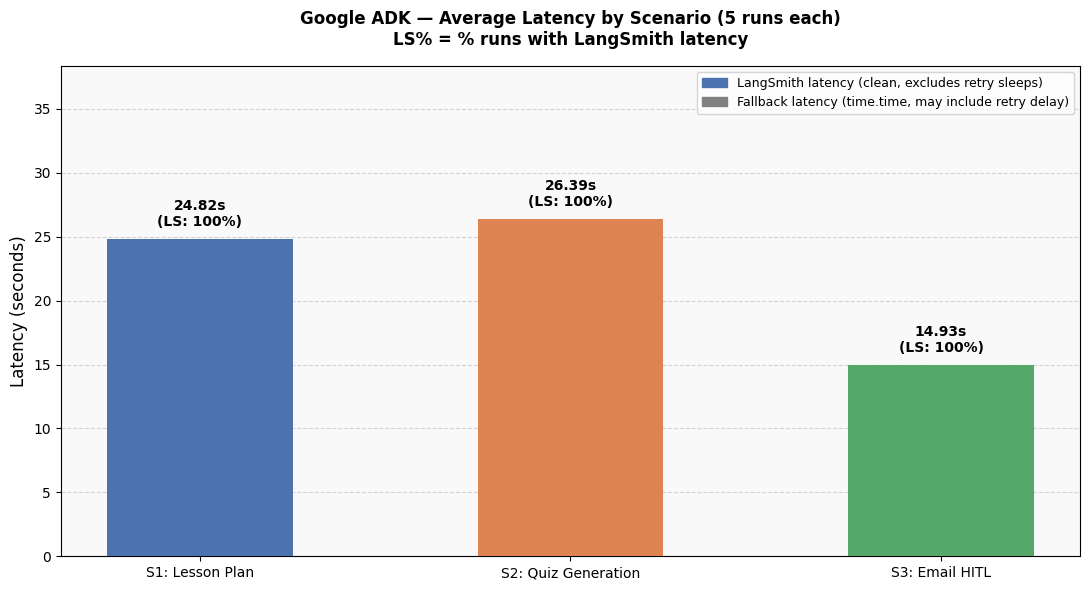

Chart saved: adk_latency_chart.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Build per-scenario stats
scenarios_raw = ["Scenario 1 - Lesson Plan", "Scenario 2 - Quiz Generation", "Scenario 3 - Email HITL"]
labels        = ["S1: Lesson Plan", "S2: Quiz Generation", "S3: Email HITL"]
colors        = ["#4C72B0", "#DD8452", "#55A868"]

avg_latencies = []
ls_pcts       = []

for s in scenarios_raw:
    subset = df[df["scenario"] == s]["latency_sec"]
    avg_latencies.append(subset.mean())
    pct = (df[df["scenario"] == s]["latency_source"] == "langsmith").mean() * 100
    ls_pcts.append(pct)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(labels, avg_latencies, color=colors, width=0.5, zorder=3)

# Value labels + latency source % on top of each bar
for bar, val, pct in zip(bars, avg_latencies, ls_pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{val:.2f}s\n(LS: {pct:.0f}%)",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title(
    "Google ADK — Average Latency by Scenario (5 runs each)\n"
    "LS% = % runs with LangSmith latency",
    fontsize=12, fontweight="bold", pad=15
)
ax.set_ylabel("Latency (seconds)", fontsize=12)
ax.set_ylim(0, max(avg_latencies) + 12)
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
ax.set_facecolor("#f9f9f9")

ls_patch = mpatches.Patch(color="#4C72B0", label="LangSmith latency (clean, excludes retry sleeps)")
fb_patch = mpatches.Patch(color="gray",    label="Fallback latency (time.time, may include retry delay)")
ax.legend(handles=[ls_patch, fb_patch], fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("adk_latency_chart.png", dpi=150)
plt.show()
print("Chart saved: adk_latency_chart.png")

from google.colab import files
files.download("adk_latency_chart.png")